In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from fairlearn.metrics import MetricFrame
import warnings
warnings.filterwarnings("ignore")

DATA_PROCESSED = Path("../data/processed")
MODELS = Path("../src/models")
FIGURES = Path("../reports/figures")

# Load model and data
xgb_model = joblib.load(MODELS / "xgboost_baseline.pkl")
X_test = pd.read_parquet(MODELS / "X_test.parquet")
y_test = np.load(MODELS / "y_test.npy")

FEATURES = [
    "forecast", "u10", "t2m", "ssrd",
    "hour", "day_of_week", "month",
    "is_weekend", "season",
    "actual_lag1", "actual_lag2", "actual_lag24",
    "rolling_mean_24h"
]
X_test.columns = FEATURES

y_pred = xgb_model.predict(X_test)

print("Setup complete")
print("Test set shape:", X_test.shape)
print("Overall R2:", round(r2_score(y_test, y_pred), 4))

Setup complete
Test set shape: (7165, 13)
Overall R2: 0.9774


In [2]:
# Define four groups to audit for bias
# These are the "protected attributes" in your fairness audit

# Group 1: Season (does model perform worse in winter vs summer?)
season_map = {0: "Winter", 1: "Spring", 2: "Summer", 3: "Autumn"}
season_labels = X_test["season"].map(season_map)

# Group 2: Time of day (peak vs off-peak)
def time_of_day(hour):
    if 7 <= hour <= 9:
        return "Morning Peak"
    elif 17 <= hour <= 20:
        return "Evening Peak"
    elif 22 <= hour or hour <= 5:
        return "Night"
    else:
        return "Off Peak"

time_labels = X_test["hour"].apply(time_of_day)

# Group 3: Weekend vs weekday
weekend_labels = X_test["is_weekend"].map({0: "Weekday", 1: "Weekend"})

# Group 4: Carbon intensity level (low/medium/high)
def carbon_level(val):
    if val < 100:
        return "Low (<100)"
    elif val < 200:
        return "Medium (100-200)"
    else:
        return "High (>200)"

carbon_labels = pd.Series(y_test).apply(carbon_level)

print("Groups defined:")
print("Seasons:", season_labels.value_counts().to_dict())
print("Time:", time_labels.value_counts().to_dict())
print("Weekend:", weekend_labels.value_counts().to_dict())
print("Carbon level:", carbon_labels.value_counts().to_dict())

Groups defined:
Seasons: {'Autumn': 3941, 'Summer': 1881, 'Winter': 1343}
Time: {'Off Peak': 2686, 'Night': 2387, 'Evening Peak': 1198, 'Morning Peak': 894}
Weekend: {'Weekday': 5236, 'Weekend': 1929}
Carbon level: {'Medium (100-200)': 3179, 'High (>200)': 2000, 'Low (<100)': 1986}


In [3]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Season audit
mf_season = MetricFrame(
    metrics={"RMSE": rmse, "MAE": mean_absolute_error, "R2": r2_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=season_labels
)

print("=== BIAS AUDIT: BY SEASON ===")
print(mf_season.by_group)
print("\nMax RMSE difference across seasons:", 
      round(mf_season.difference(method="between_groups")["RMSE"], 4))

=== BIAS AUDIT: BY SEASON ===
             RMSE       MAE        R2
season                               
Autumn  10.333600  7.646002  0.975133
Summer   9.501813  6.935205  0.965482
Winter   9.763184  7.274532  0.985741

Max RMSE difference across seasons: 0.8318


In [4]:
mf_time = MetricFrame(
    metrics={"RMSE": rmse, "MAE": mean_absolute_error, "R2": r2_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=time_labels
)

print("=== BIAS AUDIT: BY TIME OF DAY ===")
print(mf_time.by_group)
print("\nMax RMSE difference across time periods:", 
      round(mf_time.difference(method="between_groups")["RMSE"], 4))

=== BIAS AUDIT: BY TIME OF DAY ===
                   RMSE       MAE        R2
hour                                       
Evening Peak   9.172048  7.057553  0.980118
Morning Peak   9.126520  7.093190  0.980935
Night         10.888282  7.665338  0.972845
Off Peak       9.846828  7.391767  0.976894

Max RMSE difference across time periods: 1.7618


In [5]:
mf_carbon = MetricFrame(
    metrics={"RMSE": rmse, "MAE": mean_absolute_error, "R2": r2_score},
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=carbon_labels
)

print("=== BIAS AUDIT: BY CARBON LEVEL ===")
print(mf_carbon.by_group)
print("\nMax RMSE difference across carbon levels:", 
      round(mf_carbon.difference(method="between_groups")["RMSE"], 4))

=== BIAS AUDIT: BY CARBON LEVEL ===
                          RMSE       MAE        R2
sensitive_feature_0                               
High (>200)           8.846062  6.211972  0.861452
Low (<100)            9.914406  7.595475  0.672696
Medium (100-200)     10.743837  8.002250  0.866016

Max RMSE difference across carbon levels: 1.8978


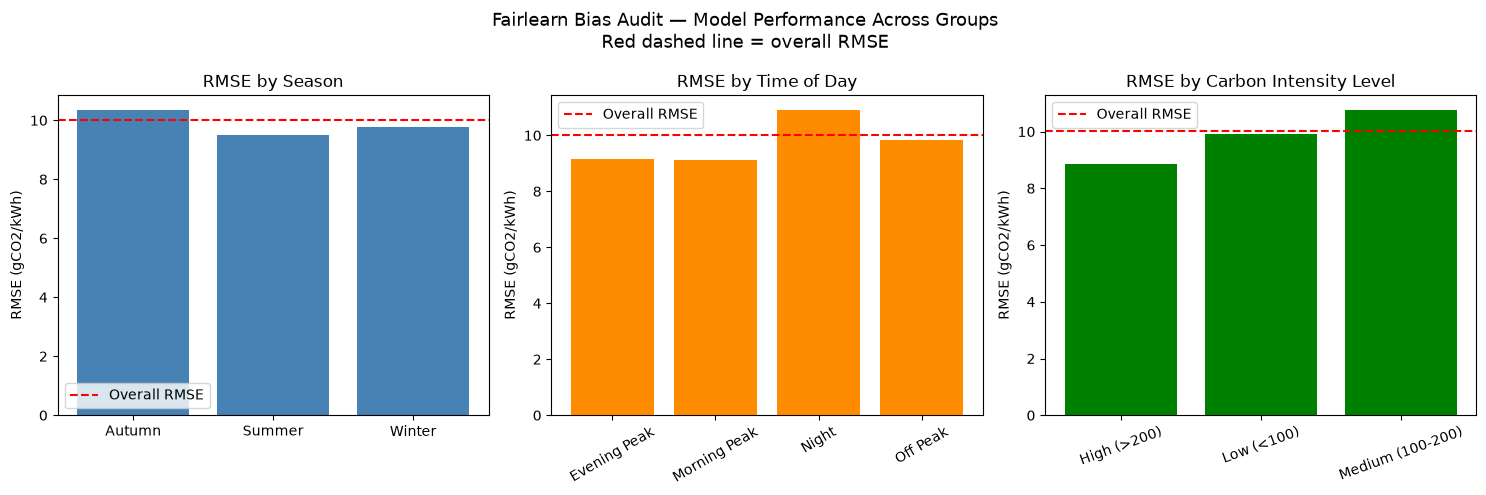

Bias audit plot saved


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Season RMSE
season_rmse = mf_season.by_group["RMSE"]
axes[0].bar(season_rmse.index, season_rmse.values, color="steelblue")
axes[0].axhline(y=mf_season.overall["RMSE"], color="red", 
                linestyle="--", label="Overall RMSE")
axes[0].set_title("RMSE by Season")
axes[0].set_ylabel("RMSE (gCO2/kWh)")
axes[0].legend()

# Time of day RMSE
time_rmse = mf_time.by_group["RMSE"]
axes[1].bar(time_rmse.index, time_rmse.values, color="darkorange")
axes[1].axhline(y=mf_time.overall["RMSE"], color="red",
                linestyle="--", label="Overall RMSE")
axes[1].set_title("RMSE by Time of Day")
axes[1].set_ylabel("RMSE (gCO2/kWh)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].legend()

# Carbon level RMSE
carbon_rmse = mf_carbon.by_group["RMSE"]
axes[2].bar(carbon_rmse.index, carbon_rmse.values, color="green")
axes[2].axhline(y=mf_carbon.overall["RMSE"], color="red",
                linestyle="--", label="Overall RMSE")
axes[2].set_title("RMSE by Carbon Intensity Level")
axes[2].set_ylabel("RMSE (gCO2/kWh)")
axes[2].tick_params(axis="x", rotation=20)
axes[2].legend()

plt.suptitle("Fairlearn Bias Audit — Model Performance Across Groups\n"
             "Red dashed line = overall RMSE", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES / "bias_audit_fairlearn.png", dpi=150, bbox_inches="tight")
plt.show()
print("Bias audit plot saved")